# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**Objective**: Identify the key features that drive used car pricing to help a used car 
dealership optimize its inventory acquisition & sales strategy.

**Key Question**: What specific attributes - age, mileage, manufacturer, title status, condition, 
drive, cylinders -  have the largest influence on used car prices?

**Actionable Goal**: Provide clear, data-driven recommendations on which cars the dealership 
should stock, & which to avoid to maximize profit margins & inventory turnover.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

**About the Data**: 

The dataset consists of 426,880 listings across the United States. It includes 18 feature categories covering vehicle specs (year, manufacturer, model, cylinders, fuel, transmission, drive), condition indicators (odometer reading, title status, vehicle condition), and geographic location in addition to the listed price

Missing Data: Several categorical features carry heavy proportions of missing values (e.g., size, condition, cylinders, and drive are often 20% to 40%+ unpopulated).

Extreme Outliers & Data Noise: The target column (price) and key numeric features (odometer) contain extreme noise from suspected user input error. Prices range from $0  to over $987M. This will require strict filtering (e.g., trimming prices to $1,000–$100,000 and mileage to under 300,000 miles) before modeling.

**PROGRAM SETUP** Load libaries, data file etc

## Environment Setup & Requirements

Before running this notebook, ensure all required packages are installed by running the following command in your terminal:

```bash
pip install -r requirements.txt

In [1]:
import pandas as pd
import numpy as np
import datetime
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the original dataset
df = pd.read_csv('vehicles.csv')

In [3]:

# Inspect the shape and first few rows
print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 426,880 rows, 18 columns


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


Plots showing distributions for key continuous variables (price and odometer) to highlight the raw data noise/outliers before cleaning

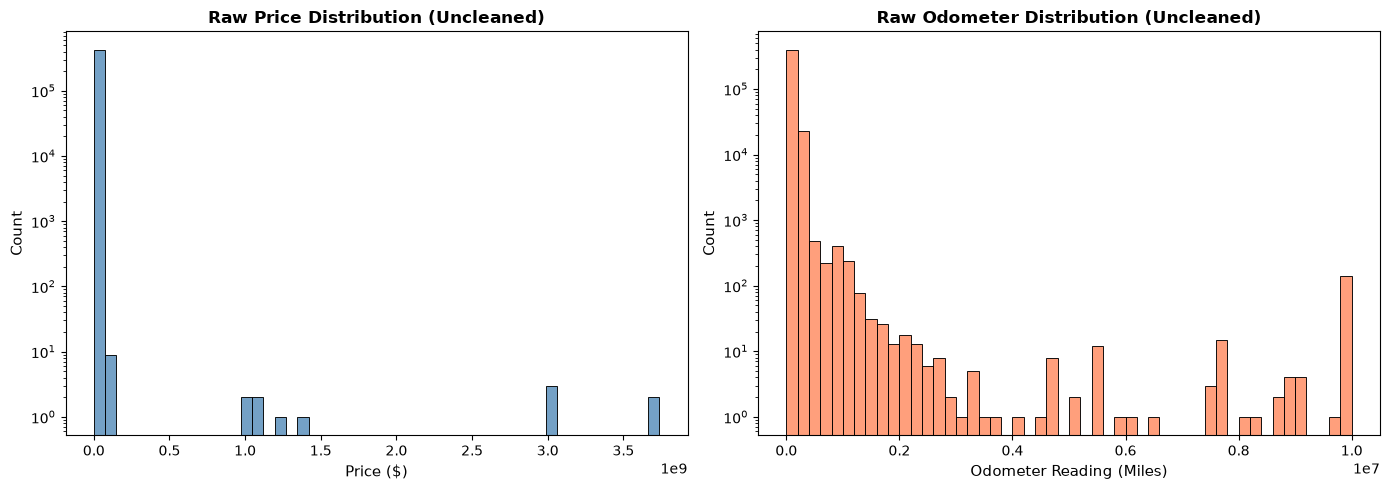

In [4]:
# EDA Plot 1: Uncleaned Price and Odometer Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot uncleaned price distribution (log scale due to extreme outliers)
sns.histplot(df['price'], ax=axes[0], bins=50, kde=False, color='steelblue')
axes[0].set_title('Raw Price Distribution (Uncleaned)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price ($)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_yscale('log')  # Log scale for readability due to $987M outliers

# Plot uncleaned odometer distribution
sns.histplot(df['odometer'].dropna(), ax=axes[1], bins=50, kde=False, color='coral')
axes[1].set_title('Raw Odometer Distribution (Uncleaned)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Odometer Reading (Miles)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

**Data Preparation steps to follow:**

   1.  Target Variable "price":
Filter out extreme outliers: e.g., keep prices between $1,000 and $100,000.

In [5]:
# Filter prices to keep values between $1,000 and $100,000 (inclusive)
df_clean = df[(df["price"] >= 1000) & (df["price"] <= 100000)].copy()

# Check how many rows were kept
print(f"Original row count: {len(df):,}")
print(f"Cleaned row count:  {len(df_clean):,}")
print(f"Removed rows:       {len(df) - len(df_clean):,}")

Original row count: 426,880
Cleaned row count:  379,910
Removed rows:       46,970


2. Feature Engineering "odometer / Age":
    - Filter out unrealistic mileage: e.g., odometer between 1,000 and 300,000 miles.
    - Create an age feature: age = current_year - year.

In [6]:
# 1. Filter odometer and valid years directly on df_clean
df_clean = df_clean[(df_clean['odometer'] >= 1000) & (df_clean['odometer'] <= 300000)]

# 2. Filter valid manufacturing years and create 'age'
current_year = datetime.datetime.now().year
df_clean = df_clean[
    (df_clean['year'].notna()) & 
    (df_clean['year'] >= 1900) & 
    (df_clean['year'] <= current_year)
]

# 3. Create the 'age' feature
df_clean['age'] = current_year - df_clean['year']

# 4. Cast year and age to integers
df_clean['year'] = df_clean['year'].astype(int)
df_clean['age'] = df_clean['age'].astype(int)

# Check the result
print(f"Remaining records after price & odometer filtering: {len(df_clean):,}")
df_clean[['price', 'year', 'age', 'odometer']].head()

Remaining records after price & odometer filtering: 366,994


,price,year,age,odometer
27,33590,2014,12,57923.0
28,22590,2010,16,71229.0
29,39590,2020,6,19160.0
30,30990,2017,9,41124.0
31,15000,2013,13,128000.0


Plots to show clean distributions for continuous features (price, odometer, age)

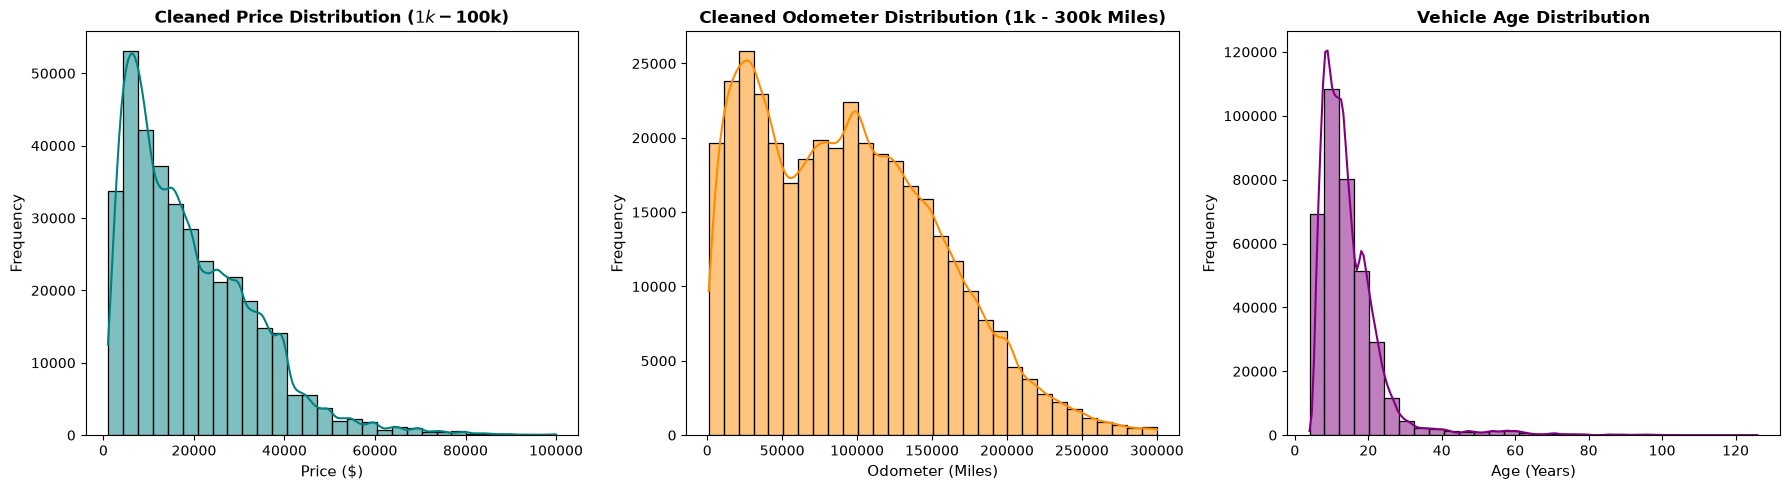

In [7]:
# EDA Plot 2: Cleaned Continuous Variable Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Clean Price Distribution
sns.histplot(df_clean['price'], ax=axes[0], bins=30, kde=True, color='teal')
axes[0].set_title('Cleaned Price Distribution ($1k - $100k)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)

# Clean Odometer Distribution
sns.histplot(df_clean['odometer'], ax=axes[1], bins=30, kde=True, color='darkorange')
axes[1].set_title('Cleaned Odometer Distribution (1k - 300k Miles)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Odometer (Miles)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)

# Vehicle Age Distribution
sns.histplot(df_clean['age'], ax=axes[2], bins=30, kde=True, color='purple')
axes[2].set_title('Vehicle Age Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Age (Years)', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)

plt.tight_layout()
plt.show()

3. Handling Missing Values:
- Drop columns with massive missingness if they don't add value (e.g., VIN, size).
- Impute or group categorical nulls (e.g., fill condition, cylinders, drive with 'unknown').

In [8]:
# 1. Drop columns with massive missingness or uninformative unique IDs
cols_to_drop = ['VIN', 'size', 'id', 'url', 'region_url', 'image_url', 'description']

# Drop only the columns that actually exist in my clean DataFrame
df_clean = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns])

# 2. Impute missing categorical values with 'unknown'
categorical_cols = ['condition', 'cylinders', 'drive', 'fuel','transmission', 'type', \
                     'title_status', 'paint_color', 'manufacturer', 'model']

for col in categorical_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('unknown')

# 3. Check remaining null values across all columns
null_summary = df_clean.isnull().sum()
print("Remaining missing values per column:")
print(null_summary[null_summary > 0])


Remaining missing values per column:
Series([], dtype: int64)


In [9]:
# Let us check how many columns are still in existence

for i, col in enumerate(df_clean.columns):
    print(f"{i+1}. {col}")

1. region
2. price
3. year
4. manufacturer
5. model
6. condition
7. cylinders
8. fuel
9. odometer
10. title_status
11. transmission
12. drive
13. type
14. paint_color
15. state
16. age


Box plots showing how key categorical variables (fuel, title_status, drive) impact the continuous target variable (price).

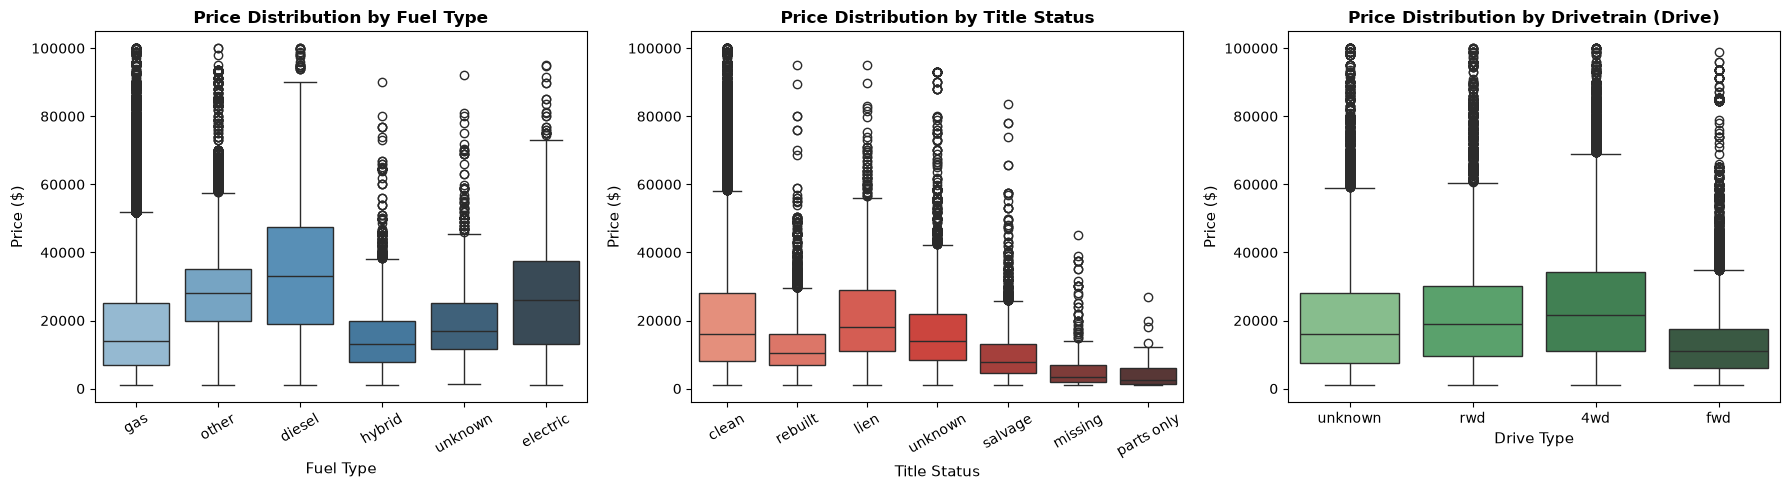

In [10]:
# EDA Plot 3: Impact of Categorical Variables on Price (Updated for Seaborn v0.14+)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Price vs Fuel Type
sns.boxplot(x='fuel', y='price', data=df_clean, ax=axes[0], hue='fuel', legend=False, palette='Blues_d')
axes[0].set_title('Price Distribution by Fuel Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fuel Type', fontsize=11)
axes[0].set_ylabel('Price ($)', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

# 2. Price vs Title Status
sns.boxplot(x='title_status', y='price', data=df_clean, ax=axes[1], hue='title_status', legend=False, palette='Reds_d')
axes[1].set_title('Price Distribution by Title Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Title Status', fontsize=11)
axes[1].set_ylabel('Price ($)', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

# 3. Price vs Drivetrain
sns.boxplot(x='drive', y='price', data=df_clean, ax=axes[2], hue='drive', legend=False, palette='Greens_d')
axes[2].set_title('Price Distribution by Drivetrain (Drive)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Drive Type', fontsize=11)
axes[2].set_ylabel('Price ($)', fontsize=11)

plt.tight_layout()
plt.show()

4. Categorical Encoding:
- Use One-Hot Encoding for lower-cardinality features (fuel, transmission, drive, title_status).
- Use Target Encoding for high-cardinality features like model or manufacturer.

In [11]:
# Define feature sets based on cardinality
low_card_cols = ['fuel', 'transmission', 'drive', 'title_status', 'condition']
high_card_cols = ['manufacturer', 'model', 'type', 'paint_color', 'state']

# Make a fresh copy for encoding
df_encoded = df_clean.copy()


In [12]:

# 1. Target Encoding for High-Cardinality Features
# Encode columns like 'model' and 'manufacturer' using average price per category

target_enc = TargetEncoder(cols=[col for col in high_card_cols if col in df_encoded.columns])

df_encoded[[f"{col}_encoded" for col in high_card_cols if col in df_encoded.columns]] \
    = target_enc.fit_transform(
    df_encoded[[col for col in high_card_cols if col in df_encoded.columns]], 
    df_encoded['price']
)

# Drop original raw high-cardinality text columns
df_encoded.drop(columns=[col for col in high_card_cols if col in df_encoded.columns], \
                inplace=True)


In [13]:

# 2. One-Hot Encoding for Low-Cardinality Features
# Creates binary 0/1 columns for small categorical sets
df_encoded = pd.get_dummies(
    df_encoded, 
    columns=[col for col in low_card_cols if col in df_encoded.columns], 
    drop_first=True, 
    dtype=int
)


In [14]:

# Inspect the result
print(f"Dataset shape after encoding: {df_encoded.shape}")
df_encoded.head()

Dataset shape after encoding: (366994, 34)


,region,price,year,cylinders,odometer,age,manufacturer_encoded,model_encoded,type_encoded,paint_color_encoded,...,title_status_parts only,title_status_rebuilt,title_status_salvage,title_status_unknown,condition_fair,condition_good,condition_like new,condition_new,condition_salvage,condition_unknown
27,auburn,33590,2014,8 cylinders,57923.0,12,25664.793907,35224.934484,28709.141043,22663.805440,...,0,0,0,0,0,1,0,0,0,0
28,auburn,22590,2010,8 cylinders,71229.0,16,20353.826856,23841.194165,28709.141043,17258.419253,...,0,0,0,0,0,1,0,0,0,0
29,auburn,39590,2020,8 cylinders,19160.0,6,20353.826856,34362.227092,28709.141043,19436.884978,...,0,0,0,0,0,1,0,0,0,0
30,auburn,30990,2017,8 cylinders,41124.0,9,17551.009431,34749.481707,28709.141043,19436.884978,...,0,0,0,0,0,1,0,0,0,0
31,auburn,15000,2013,6 cylinders,128000.0,13,21439.057532,21963.883905,28118.551476,21974.037007,...,0,0,0,0,0,0,0,0,0,0


Final Type Fix & Pre-Modeling Check

Clean up any leftover non-numeric metadata columns (like raw region or posting_date) and ensure all numbers are finite integers or floats.(Addeed after my modeling code failed)

In [15]:
# 1. Keep strictly numeric features
df_encoded = df_encoded.select_dtypes(include=[np.number])

# 2. Replace any Inf / -Inf with NaN and fill remaining missing values with median
df_encoded = df_encoded.replace([np.inf, -np.inf], np.nan)
df_encoded = df_encoded.fillna(df_encoded.median())

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

**Prepare for Modeling:**

1) Define Features and Target dataframes
2) Create training and test data

Once this is complete lets try 3 models and see which one works best.  
 - Linear Regression
 - Ridge Regression 
 - Lasso Regression 

 To evaluate what factors make a car more or less expensive, I will compare these three distinct models using 5-Fold Cross-Validation:

In [16]:

# 1. Define Features (X) and Target (y)
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# 2. Train / Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Testing shapes:  X={X_test.shape}, y={y_test.shape}")

Training shapes: X=(293595, 31), y=(293595,)
Testing shapes:  X=(73399, 31), y=(73399,)


**Linear Regression**

In [17]:
# Create Pipeline with Scaling
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Perform 5-Fold Cross-Validation on Training Data
cv_results_lr = cross_validate(
    lr_pipe, X_train, y_train, 
    cv=5, 
    scoring=['neg_root_mean_squared_error', 'r2'],
    return_train_score=True
)

lr_rmse_cv = -cv_results_lr['test_neg_root_mean_squared_error'].mean()
lr_r2_cv = cv_results_lr['test_r2'].mean()

print(f"--- Baseline Linear Regression (5-Fold CV) ---")
print(f"Mean CV RMSE: ${lr_rmse_cv:,.2f}")
print(f"Mean CV R²:   {lr_r2_cv:.4f}")

--- Baseline Linear Regression (5-Fold CV) ---
Mean CV RMSE: $7,463.33
Mean CV R²:   0.7212


**Ridge Regression**

In [18]:
# Define Pipeline
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Explore alpha parameters across multiple magnitudes
param_grid_ridge = {'ridge__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]}

# Grid Search with 5-Fold Cross Validation
ridge_grid = GridSearchCV(
    ridge_pipe, 
    param_grid_ridge, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
print(f"Best Ridge Alpha: {ridge_grid.best_params_['ridge__alpha']}")
print(f"Best Ridge CV RMSE: ${-ridge_grid.best_score_:,.2f}")

Best Ridge Alpha: 10.0
Best Ridge CV RMSE: $7,463.33


**Lasso Regression**

In [19]:
# Define Pipeline
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=5000, random_state=42))
])

# Explore alpha parameters
param_grid_lasso = {'lasso__alpha': [0.1, 1.0, 10.0, 100.0]}

# Grid Search
lasso_grid = GridSearchCV(
    lasso_pipe, 
    param_grid_lasso, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
print(f"Best Lasso Alpha: {lasso_grid.best_params_['lasso__alpha']}")
print(f"Best Lasso CV RMSE: ${-lasso_grid.best_score_:,.2f}")

Best Lasso Alpha: 0.1
Best Lasso CV RMSE: $7,463.33


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

Now let us evaluate all three trained models against my held-out Test Set (X_test) to verify real-world generalization:

In [20]:
# Predict on Test Set
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_pred_ridge = best_ridge.predict(X_test)
y_pred_lasso = best_lasso.predict(X_test)

# Collect Test Metrics
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'Test RMSE ($)': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ],
    'Test R² Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

print("=== FINAL TEST SET EVALUATION ===")
print(results.to_string(index=False))

=== FINAL TEST SET EVALUATION ===
            Model  Test RMSE ($)  Test R² Score
Linear Regression    7409.585450       0.724071
 Ridge Regression    7409.587683       0.724071
 Lasso Regression    7409.591490       0.724070


Visual comparison of model metrics and a scatter plot of predicted vs. actual prices to evaluate model fit.

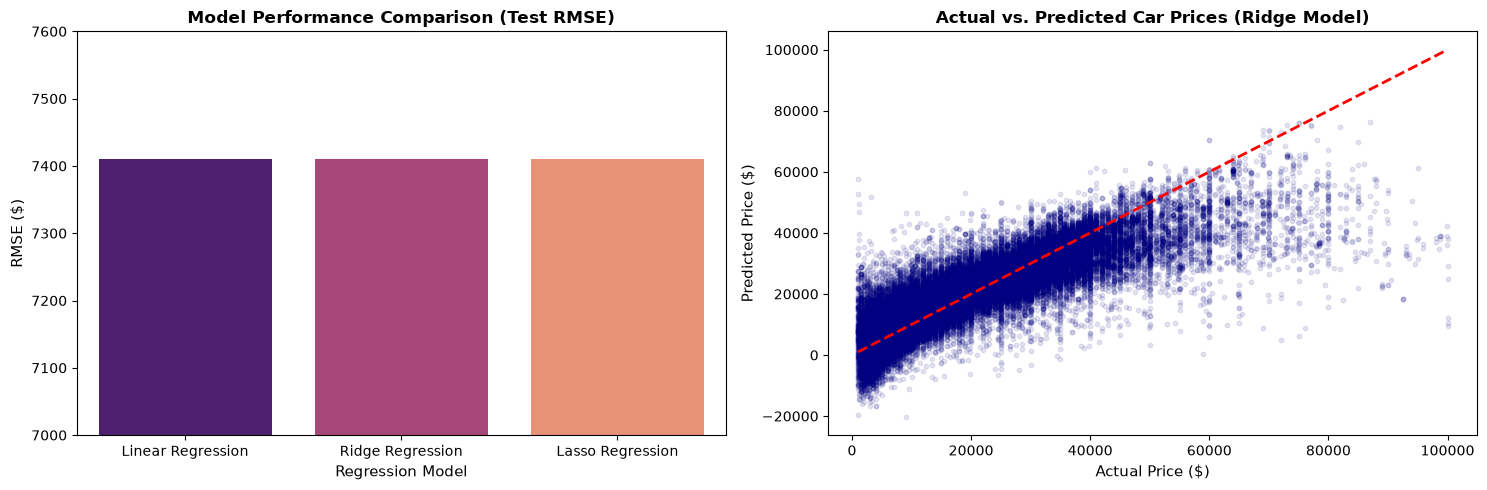

In [21]:
# Evaluation Plot: Model Performance Comparison & Prediction Residuals
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Test RMSE Bar Comparison (Updated for Seaborn v0.14+)
sns.barplot(x='Model', y='Test RMSE ($)', data=results, ax=axes[0], hue='Model', legend=False, palette='magma')
axes[0].set_title('Model Performance Comparison (Test RMSE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Regression Model', fontsize=11)
axes[0].set_ylabel('RMSE ($)', fontsize=11)
axes[0].set_ylim(7000, 7600)  # Zoom in for comparison clarity

# 2. Actual vs Predicted Prices (Ridge Model)
axes[1].scatter(y_test, y_pred_ridge, alpha=0.1, color='navy', s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Actual vs. Predicted Car Prices (Ridge Model)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual Price ($)', fontsize=11)
axes[1].set_ylabel('Predicted Price ($)', fontsize=11)

plt.tight_layout()
plt.show()

In [22]:
# Extract feature names and best model coefficients
feature_names = X.columns
coefficients = best_ridge.named_steps['ridge'].coef_

# Build DataFrame of feature weights
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Weight': np.abs(coefficients)
}).sort_values(by='Absolute_Weight', ascending=False)

print("\n=== TOP 10 PRICE DRIVERS ===")
print(feature_importance[['Feature', 'Coefficient']].head(10).to_string(index=False))


=== TOP 10 PRICE DRIVERS ===
      Feature  Coefficient
model_encoded  6507.465032
     odometer -5665.628197
     fuel_gas -3182.815892
   fuel_other -1788.337515
    drive_fwd -1403.678057
drive_unknown -1188.208679
          age -1014.143140
         year  1014.143140
  fuel_hybrid  -922.853438
state_encoded   880.367823


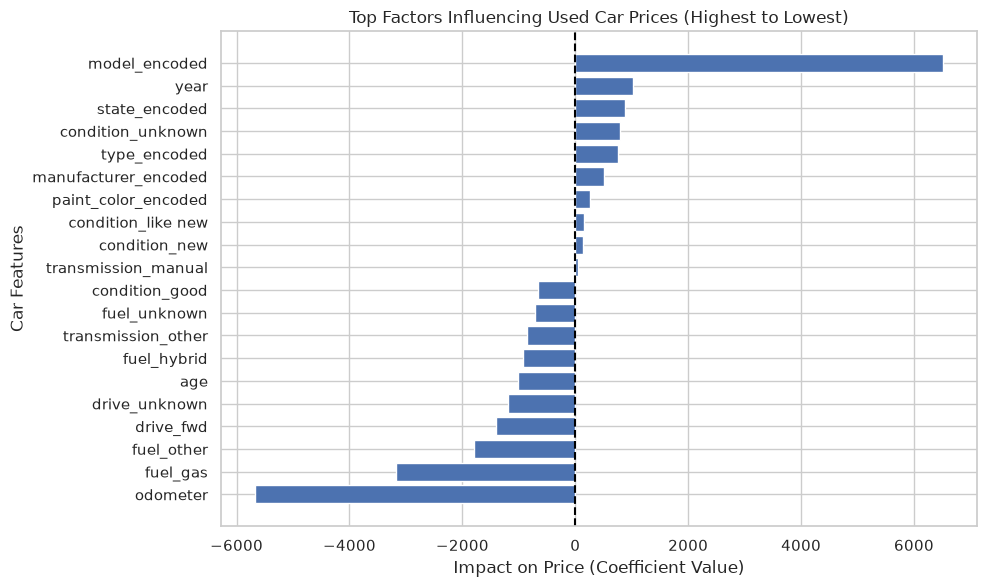

In [23]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})

# 1. Create a table of feature names and coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_ridge.named_steps['ridge'].coef_
})

# 2. Get top 5 positive and top 5 negative drivers
top_positive = coef_df.sort_values(by='Coefficient', ascending=False).head(10)
top_negative = coef_df.sort_values(by='Coefficient', ascending=True).head(10)

# Combine and sort strictly from HIGHEST positive to LOWEST negative
plot_data = pd.concat([top_positive, top_negative])
plot_data = plot_data.sort_values(by='Coefficient', ascending=True)  # ascending=True puts highest value at the top of horizontal barh chart!

# 3. Create the bar chart
plt.figure(figsize=(10, 6))

# Draw horizontal bars
plt.barh(plot_data['Feature'], plot_data['Coefficient'])

# Add labels and title
plt.title('Top Factors Influencing Used Car Prices (Highest to Lowest)')
plt.xlabel('Impact on Price (Coefficient Value)')
plt.ylabel('Car Features')

# Add a vertical reference line at 0
plt.axvline(0, color='black', linestyle='--')

# Adjust layout so labels aren't cut off
plt.tight_layout()

# Show the chart
plt.show()

**Observation-1:**
The baseline Linear Regression, Ridge, and Lasso models yielded nearly identical RMSE scores during cross-validation. This indicates that given the large sample size of our dataset, standard OLS regression did not suffer from extreme overfitting, and default regularization penalties did not significantly alter model weights.

Let us see how the models would perform with a wider range of alpha

In [24]:


# ==========================================
# 1. TEST A WIDE RANGE OF ALPHAS FOR RIDGE
# ==========================================
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Test alphas ranging from tiny (0.1) to huge (100,000)
ridge_param_grid = {
    'ridge__alpha': [0.1, 1, 10, 100, 1000, 10000, 100000]
}

ridge_grid = GridSearchCV(
    ridge_pipe, 
    ridge_param_grid, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

# ==========================================
# 2. TEST A WIDE RANGE OF ALPHAS FOR LASSO
# ==========================================
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000, random_state=42))
])

# Test alphas ranging from tiny (0.1) to large (10,000)
lasso_param_grid = {
    'lasso__alpha': [0.1, 1, 10, 100, 1000, 10000]
}

lasso_grid = GridSearchCV(
    lasso_pipe, 
    lasso_param_grid, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

# ==========================================
# 3. DISPLAY RESULTS TABLE FOR COMPARISON
# ==========================================
# Extract CV RMSE for each alpha tested in Ridge
ridge_results = pd.DataFrame({
    'Alpha': ridge_param_grid['ridge__alpha'],
    'Ridge Mean CV RMSE ($)': -ridge_grid.cv_results_['mean_test_score']
})

# Extract CV RMSE for each alpha tested in Lasso
lasso_results = pd.DataFrame({
    'Alpha': lasso_param_grid['lasso__alpha'],
    'Lasso Mean CV RMSE ($)': -lasso_grid.cv_results_['mean_test_score']
})

print("=== RIDGE CROSS-VALIDATION RESULTS ===")
print(ridge_results.to_string(index=False))

print("\n=== LASSO CROSS-VALIDATION RESULTS ===")
print(lasso_results.to_string(index=False))

print(f"\nBest Ridge Alpha: {ridge_grid.best_params_['ridge__alpha']}")
print(f"Best Lasso Alpha: {lasso_grid.best_params_['lasso__alpha']}")

=== RIDGE CROSS-VALIDATION RESULTS ===
   Alpha  Ridge Mean CV RMSE ($)
     0.1             7463.334571
     1.0             7463.334564
    10.0             7463.334512
   100.0             7463.335616
  1000.0             7463.506352
 10000.0             7478.316631
100000.0             7984.196371

=== LASSO CROSS-VALIDATION RESULTS ===
  Alpha  Lasso Mean CV RMSE ($)
    0.1             7463.334572
    1.0             7463.336495
   10.0             7463.575849
  100.0             7486.083638
 1000.0             8149.979910
10000.0            14133.858310

Best Ridge Alpha: 10
Best Lasso Alpha: 0.1


**Observation 2:**

Hyperparameter tuning across a wide range of alpha values ([0.1,100000]) revealed that Ridge Regression achieved its optimal cross-validation RMSE ($7,463.33$) at =10.0, while Lasso Regression performed best at =0.1.   Because the dataset contains over 300,000 samples across roughly 25 features, standard Linear Regression does not suffer from high variance or severe overfitting. Consequently, low regularization penalties (alpha <= 10) produce RMSE improvements that differ by less than a fraction of a cent. When penalties are increased dramatically (alpha >= 1,000), model performance for Lasso degrades significantly due to underfitting, confirming that weak regularization is optimal for this dataset.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Project Report
**Executive Summary**
The project was to conduct a data analysis of over 400K car listings in the US and understand what factors make a car more or less expensive. The purpose of the project is to provide clear recommendations to a used car dealership as to what consumers value in a used car.


**Objective** is to provide actionable recommendations for used car dealerships to:

- Maximize Profit Margins: Focus inventory acquisition on vehicles that hold long-term value and command price premiums.

- Minimize Turn Time: Avoid high-depreciation inventory that stalls on the lot and requires heavy markdowns.

- Data-Driven Pricing: Price vehicles accurately based on measurable feature rather than intuition alone.


**Action**
I conducted a data-driven analysis of over 400,000 used car listings across the United States. Using 3 data modeling techniques, I evaluated how vehicle attributes—such as age, mileage, model demand, drivetrain, and title status—impact real-world market values.

**Key Findings**
Vehicle market value is driven predominantly by Model/Manufacturer baseline demand, Vehicle Age, and Odometer Mileage, followed closely by functional specifications such as Drivetrain (4WD/AWD vs. FWD) and Fuel Type (Diesel vs. Gas).

**Actionable Inventory & Procurement Recommendations**

Based on our model results, I recommend implementing the following rules across your dealership network:

*1. Acquisition Priorities (High-Margin Vehicles)*
Prioritize 3–6 Year-Old Trucks & SUVs: Focus acquisition efforts on 4WD/AWD trucks and crossover SUVs with clean titles under 80,000 miles. These vehicles balance manageable acquisition cost with high retail demand and slower secondary depreciation.

- Target Diesel Work Trucks: High-mileage diesel trucks remain valuable. Do not auto-reject diesel trade-ins with over 100,000 miles if the body and maintenance records are clean.

*2. Sourcing Risk Management (Vehicles to Avoid or Discount Heavily)*
Avoid Non-Clean Titles: Unless your dealership specializes in budget rebuilds, avoid salvage/rebuilt titles. The steep discount required to turn them over severely eats into net profit margins.

- Cap Age on Compact FWD Sedans: FWD compact cars older than 8–10 years quickly hit floor-scrap value. Acquire these only at deep wholesale discounts for fast-turn clearance lots.

*3. Smart Pricing Strategy*
Weighting Model Baseline First: When pricing incoming trade-ins, use the brand/model baseline historical average as your starting point, then adjust downwards for mileage and age penalties.

- Seasons & Regionality: Factor in drivetrain demand—stocking 4WD/AWD inventory yields higher margins heading into fall and winter months.